# Assignment: TorchVision Transfer Learning with Fast-Food Classification

## Learning Goals

By the end of this assignment, you should be able to:

- Load image datasets with `torchvision.datasets.ImageFolder`
- Build preprocessing pipelines with `transforms.Compose()`
- Apply resizing, center cropping, normalization, and other augmentations
- Visualize original and transformed images
- Use a pre-trained model for transfer learning
- Fine-tune a partially unfrozen backbone

## Dataset

We will use the Fast-Food Classification dataset, which is already downloaded and cleaned for you.  
Your job is to focus on the TorchVision workflow and the transfer learning steps.

## 0. Setup

In [8]:
import os
import shutil
from PIL import Image

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import ResNet50_Weights, resnet50

Run the following cells to download and unpack the data

In [9]:
#!/bin/bash
!curl -L -o archive.zip https://www.kaggle.com/api/v1/datasets/download/utkarshsaxenadn/fast-food-classification-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  820M  100  820M    0     0  81.7M      0  0:00:10  0:00:10 --:--:--  126M


In [10]:
!unzip -q archive.zip

In [11]:
# Adjust this path if your dataset lives somewhere else
DATA_ROOT = Path("./Fast Food Classification V2")
TRAIN_DIR = DATA_ROOT / "Train"
VALID_DIR = DATA_ROOT / "Valid"
TEST_DIR = DATA_ROOT / "Test"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

LEARNING_RATE = 1e-3

NUMBER_OF_EPOCHS = 5

torch.manual_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


To speed up training time, we reduce the dataset to three classes

In [12]:
directories = [
    TRAIN_DIR,
    VALID_DIR,
    TEST_DIR,
]

classes_to_keep = ["Pizza", "Hot Dog", "Burger"]

for dir_path in directories:
  for class_folder in os.listdir(dir_path):
    class_folder_path = os.path.join(dir_path, class_folder)

    if os.path.isdir(class_folder_path) and class_folder not in classes_to_keep:
      print(f"Removing folder: {class_folder_path}")
      shutil.rmtree(class_folder_path)

print("Folder cleanup completed.")

Removing folder: Fast Food Classification V2/Train/Taquito
Removing folder: Fast Food Classification V2/Train/Crispy Chicken
Removing folder: Fast Food Classification V2/Train/Donut
Removing folder: Fast Food Classification V2/Train/Sandwich
Removing folder: Fast Food Classification V2/Train/Baked Potato
Removing folder: Fast Food Classification V2/Train/Taco
Removing folder: Fast Food Classification V2/Train/Fries
Removing folder: Fast Food Classification V2/Valid/Taquito
Removing folder: Fast Food Classification V2/Valid/Crispy Chicken
Removing folder: Fast Food Classification V2/Valid/Donut
Removing folder: Fast Food Classification V2/Valid/Sandwich
Removing folder: Fast Food Classification V2/Valid/Baked Potato
Removing folder: Fast Food Classification V2/Valid/Taco
Removing folder: Fast Food Classification V2/Valid/Fries
Removing folder: Fast Food Classification V2/Test/Taquito
Removing folder: Fast Food Classification V2/Test/Crispy Chicken
Removing folder: Fast Food Classificati

The data may contain corrupt or improperly formatted images. Running the following cell cleans them up.

In [13]:
supported_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}

def delete_invalid_images(directory):
    """Goes through a directory and deletes any invalid or unsupported images."""
    print(f"Checking directory: {directory}")
    check_directory = os.path.exists(directory)
    if not check_directory:
        print(f"Directory does not exist: {directory}")
        return
    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)

            if not any(file.lower().endswith(ext) for ext in supported_extensions):
                print(f"Deleting unsupported file: {file_path}")
                os.remove(file_path)
                continue

            try:
                with Image.open(file_path) as img:
                    img.load()  # Ensure the image content can be read
                    if img.format not in ["JPEG", "PNG", "GIF", "BMP"]:
                        raise IOError("Unsupported image format")

                    if img.format == "PNG" and img.mode != "RGBA":
                        print(f"Converted image to RGBA: {file_path}")
                        img.convert("RGBA").save(file_path)

            except (IOError, SyntaxError, AttributeError) as e:
                print(f"Deleting invalid or corrupted image: {file_path}")
                os.remove(file_path)

for dir_path in directories:
    delete_invalid_images(dir_path)

print("Invalid and unsupported image cleanup completed.")

Checking directory: Fast Food Classification V2/Train
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (3).png
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (15).png
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (4).png
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (11).png
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (7).png
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (17).png
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (12).png
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (1).png
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (8).png
Converted image to RGBA: Fast Food Classification V2/Train/Hot Dog/Hot Dog - Train (5).png
Deleting invalid or corrupted im

## Utility Cells

The cells below are provided so that the focus of the assignment stays on the TorchVision parts instead of boilerplate training and visualization code.


In [14]:
def denormalize(image_tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return image_tensor * std + mean


def show_original_and_transformed(raw_dataset, transformed_dataset, class_names, indices):
    fig, axes = plt.subplots(len(indices), 2, figsize=(10, 4 * len(indices)))
    if len(indices) == 1:
        axes = [axes]

    for row, idx in enumerate(indices):
        original_image, label = raw_dataset[idx]
        transformed_image, transformed_label = transformed_dataset[idx]

        axes[row][0].imshow(original_image)
        axes[row][0].set_title(f"Original: {class_names[label]}")
        axes[row][0].axis("off")

        transformed_image = denormalize(transformed_image.cpu(), IMAGENET_MEAN, IMAGENET_STD)
        transformed_image = transformed_image.clamp(0, 1).permute(1, 2, 0).numpy()
        axes[row][1].imshow(transformed_image)
        axes[row][1].set_title(f"Transformed: {class_names[transformed_label]}")
        axes[row][1].axis("off")

    plt.tight_layout()
    plt.show()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def fit_model(model, train_loader, valid_loader, optimizer, criterion, device, epochs):
    history = {
        "train_loss": [],
        "train_acc": [],
        "valid_loss": [],
        "valid_acc": [],
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
            f"valid loss: {valid_loss:.4f}, valid acc: {valid_acc:.4f}"
        )

    return history


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(epochs, history["train_loss"], label="train")
    ax[0].plot(epochs, history["valid_loss"], label="valid")
    ax[0].set_title(f"{title} - Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(epochs, history["train_acc"], label="train")
    ax[1].plot(epochs, history["valid_acc"], label="valid")
    ax[1].set_title(f"{title} - Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

## Task 1: Build the preprocessing pipelines

Create two preprocessing pipelines with `transforms.Compose()`:

- A **training** transform that includes:
  - resizing to 256 x 256 pixels
  - center cropping to the `IMAGE_SIZE` defined above
  - normalization
  - **three suitable augmentations of your choice**
- A **validation/test** transform that includes:
  - resizing
  - center cropping
  - normalization

Use the ImageNet mean and standard deviation because we will use a pre-trained ResNet-50.


In [15]:
# TODO: Research and define the ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# TODO: Build `train_transform` with Resize, CenterCrop, three augmentations of your choice, ToTensor and Normalize
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ColorJitter(brightness=0.5, contrast=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ]
)

# TODO: Build `eval_transform` with Resize, CenterCrop, ToTensor and Normalize
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ]
)

## Task 2: Load the datasets and create dataloaders

Use `torchvision.datasets.ImageFolder` to load the train, validation, and test folders.

Then create `DataLoader` objects for all three splits.


In [16]:
# TODO:
#  - Load the three datasets with ImageFolder
#  - Use the training transform for the training data
#  - Use the evaluation transform for validation and test data

raw_train_dataset = datasets.ImageFolder(root=TRAIN_DIR)
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)
valid_dataset = datasets.ImageFolder(
    root=VALID_DIR,
    transform=eval_transform
)
test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transform
)

# TODO: Create dataloaders for train, validation, and test
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset,batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE, shuffle=False)

# TODO: Extract the number of classes and the class labels
num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

print("Number of classes:", num_classes)
print("Classes:", class_names)

Number of classes: 3
Classes: ['Burger', 'Hot Dog', 'Pizza']


## Task 3: Visualize original and transformed images

Select a few examples from the training set for each class and display:

- the original image
- the transformed image

This is a good sanity check to see whether your preprocessing is appropriate and behaves as expected.

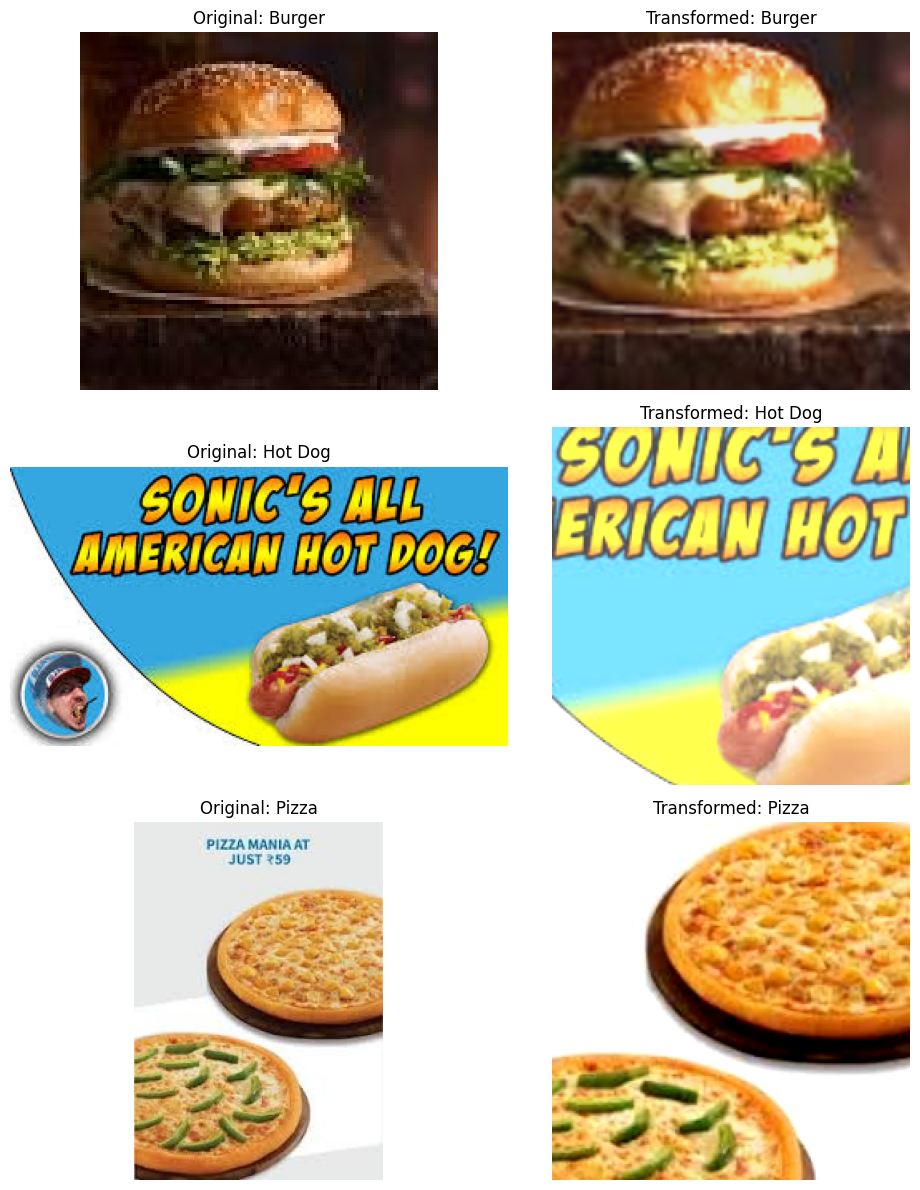

In [17]:
# TODO: Create a small list of sample indices with at least two samples per class (hint: check the number of images per class in the data directory)
sample_indices = [0, 1600, 3500] # Example indices, adjust based on your dataset

# TODO: Visualize the original and transformed version of each sample side by side using the helper function defined above
show_original_and_transformed(raw_train_dataset, train_dataset, class_names, sample_indices)

Selected indices for visualization: [0, 1, 1500, 1501, 2999, 3000]


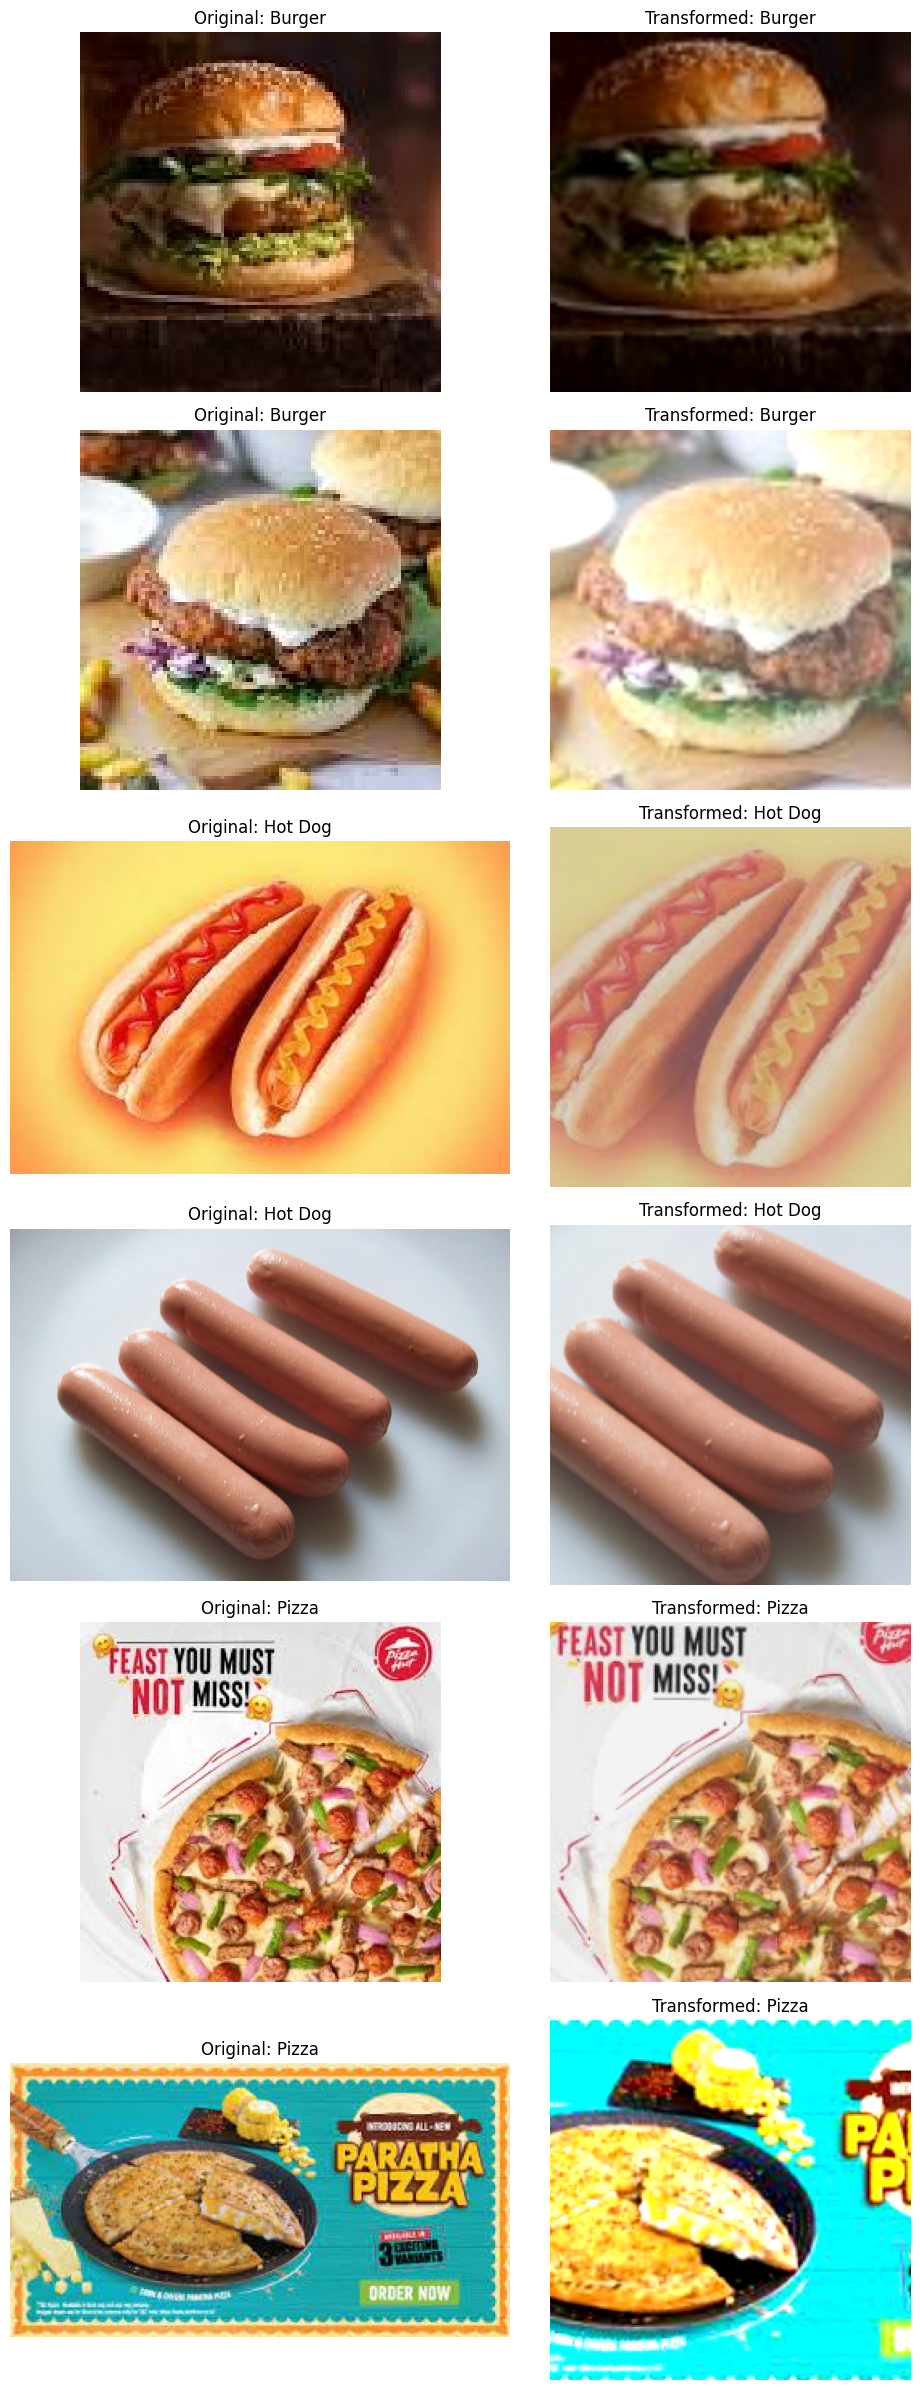

In [18]:
# Programmatically select sample indices to ensure at least two from each class
correct_sample_indices = []
num_samples_per_class = 2

# train_dataset.targets contains the class index for each image
# train_dataset.class_to_idx maps class names to their indices

# Create a dictionary to hold indices for each class
class_indices = {class_idx: [] for class_idx in range(num_classes)}

for i, target in enumerate(train_dataset.targets):
    class_indices[target].append(i)

# Select `num_samples_per_class` from each class
for class_idx in range(num_classes):
    correct_sample_indices.extend(class_indices[class_idx][:num_samples_per_class])

print(f"Selected indices for visualization: {correct_sample_indices}")

# Visualize the original and transformed version of each sample side by side
show_original_and_transformed(raw_train_dataset, train_dataset, class_names, correct_sample_indices)

## Task 4: Build a ResNet-50 transfer learning model

Define a function to initialize a pre-trained ResNet-50 model for **feature extraction**:

- load a pre-trained ResNet-50 backbone
- freeze all backbone parameters
- replace the final classification layer so that it matches your number of classes


In [20]:
def initialize_model():
    from torchvision.models import ResNet50_Weights, resnet50 # Added for robustness against NameError
    import torch.nn as nn # Added for robustness against NameError
    # TODO: Set the weights to an appropriate value to load a pre-trained model (hint: look at the documentation of resnet50())
    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)

    # TODO: Freeze all parameters
    for param in model.parameters():
      param.requires_grad = False

    # TODO: Replace the classification head with a new layer for `num_classes`
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features=in_features, out_features=num_classes)

    # TODO: Make the new classification head trainable

    # The new fc layer's parameters are trainable by default since they were added after freezing the base.
    # So, this step is implicitly handled if the order is followed.

    # TODO: Move the model to the correct device
    model = model.to(device)

    return model

model = initialize_model()

print(model.fc)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Linear(in_features=2048, out_features=3, bias=True)
Trainable parameters: 6147


## Task 5: Train the frozen model

Train only the new classification head for a few epochs.

Use a standard classification loss and an optimizer that only sees the trainable parameters.


Epoch 01 | train loss: 0.5030, train acc: 0.8604 | valid loss: 0.3874, valid acc: 0.8778
Epoch 02 | train loss: 0.2704, train acc: 0.9189 | valid loss: 0.3063, valid acc: 0.9011
Epoch 03 | train loss: 0.2229, train acc: 0.9327 | valid loss: 0.2635, valid acc: 0.9111
Epoch 04 | train loss: 0.1976, train acc: 0.9400 | valid loss: 0.2499, valid acc: 0.9122
Epoch 05 | train loss: 0.1801, train acc: 0.9435 | valid loss: 0.2791, valid acc: 0.8989


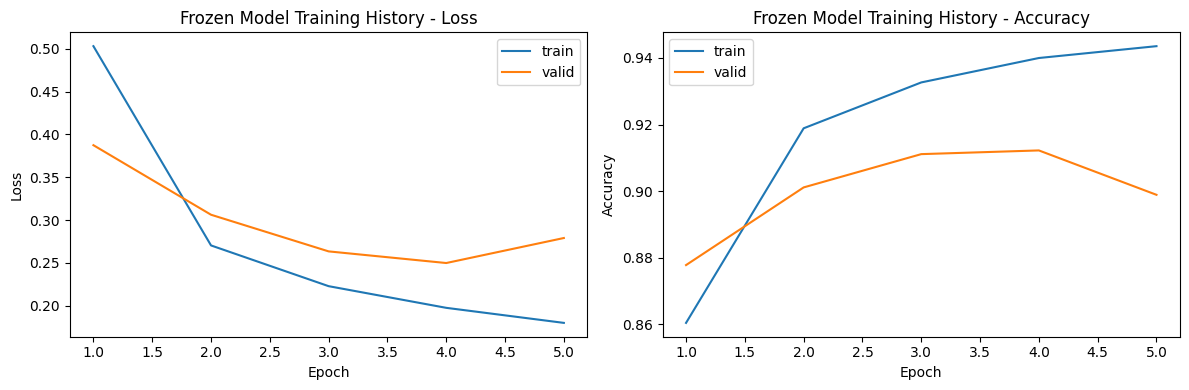

In [22]:
# TODO: Choose a loss function and an optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# TODO: Train the model for a few epochs using the helper function defined above
history_frozen = fit_model(model, train_loader, valid_loader, optimizer, criterion, device, NUMBER_OF_EPOCHS)

# TODO: Plot the training history using the helper function defined above
plot_history(history_frozen, "Frozen Model Training History")

## Task 6: Unfreeze and fine-tune more layers

Now unfreeze the last ResNet block and fine-tune the model with a smaller learning rate.

A common strategy is to:

- keep early layers frozen
- unfreeze `layer4`
- continue training for a few more epochs


Epoch 01 | train loss: 0.7934, train acc: 0.7897 | valid loss: 0.6438, valid acc: 0.8611
Epoch 02 | train loss: 0.4904, train acc: 0.9006 | valid loss: 0.5049, valid acc: 0.8789
Epoch 03 | train loss: 0.4019, train acc: 0.9038 | valid loss: 0.4517, valid acc: 0.8789
Epoch 04 | train loss: 0.3537, train acc: 0.9115 | valid loss: 0.4101, valid acc: 0.8844
Epoch 05 | train loss: 0.3270, train acc: 0.9124 | valid loss: 0.3783, valid acc: 0.8944


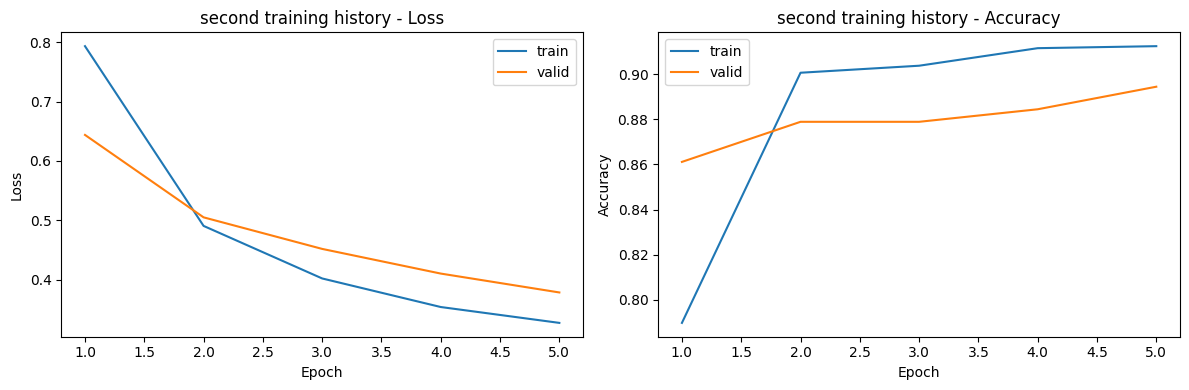

In [24]:
model = initialize_model()

# TODO: Unfreeze the last residual block (`layer4`)
for param in model.layer4.parameters():
  param.requires_grad= False

# TODO: Create a new optimizer for all trainable parameters (use the learning rate defined above)
optimizer = optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=0.9
)

# TODO: Re-train the model for a few epochs
history_fine_tune = fit_model(model, train_loader, valid_loader, optimizer, criterion, device, NUMBER_OF_EPOCHS)

# TODO: Plot the second training history
plot_history(history_fine_tune, "second training history")

## Task 7: Evaluate on the test set

Finally, evaluate the fine-tuned model on the test set.

In [26]:
# TODO: Evaluate the fine-tuned model on the test loader using the evaluate() helper function defined above
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.3649
Test accuracy: 0.8983
